In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import shutil

DATASET_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)

Images: /content/drive/MyDrive/Cellula/WaterSegmentation/data/images
Labels: /content/drive/MyDrive/Cellula/WaterSegmentation/data/labels


In [3]:
image_files = sorted([
    p for p in IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in [".tif", ".tiff"]
])

label_files = sorted([
    p for p in LABELS_DIR.iterdir()
    if p.is_file() and p.suffix.lower() == ".png"
])

print(f"Number of images: {len(image_files)}")
print(f"Number of labels: {len(label_files)}")

print("\nFirst 10 image files:")
for p in image_files[:10]:
    print(p.name)

print("\nFirst 10 label files:")
for p in label_files[:10]:
    print(p.name)

Number of images: 306
Number of labels: 306

First 10 image files:
0.tif
1.tif
10.tif
100.tif
101.tif
102.tif
103.tif
104.tif
105.tif
106.tif

First 10 label files:
0.png
1.png
10.png
100.png
101.png
102.png
103.png
104.png
105.png
106.png


In [4]:
sample_path = image_files[0]

with rasterio.open(sample_path) as src:
    print("File:", sample_path.name)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)
    print("Shape:", (src.height, src.width, src.count))
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Transform:", src.transform)
    print("Descriptions:", src.descriptions)
    print("Metadata:", src.meta)
    print("Tags:", src.tags())

    print("\nBand statistics:")
    for i in range(1, src.count + 1):
        band = src.read(i)
        print(
            f"Band {i}: "
            f"min={np.nanmin(band)}, "
            f"max={np.nanmax(band)}, "
            f"mean={np.nanmean(band):.4f}"
        )

File: 0.tif
Width: 128
Height: 128
Bands: 12
Shape: (128, 128, 12)
Dtype: ('int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16')
CRS: None
Resolution: (1.0, 1.0)
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Descriptions: (None, None, None, None, None, None, None, None, None, None, None, None)
Metadata: {'driver': 'GTiff', 'dtype': 'int16', 'nodata': None, 'width': 128, 'height': 128, 'count': 12, 'crs': None, 'transform': Affine(1.0, 0.0, 0.0,
       0.0, 1.0, 0.0)}
Tags: {}

Band statistics:
Band 1: min=14, max=532, mean=174.0609
Band 2: min=-28, max=846, mean=166.0735
Band 3: min=-2, max=1099, mean=326.9439
Band 4: min=2, max=1297, mean=325.7662
Band 5: min=46, max=4975, mean=1945.2276
Band 6: min=30, max=3786, mean=1298.1793
Band 7: min=16, max=3004, mean=678.8449
Band 8: min=64, max=160, mean=66.3398
Band 9: min=130, max=355, mean=246.9894
Band 10: min=172, max=404, mean=291.1042
Band 11: min=10, max=90

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


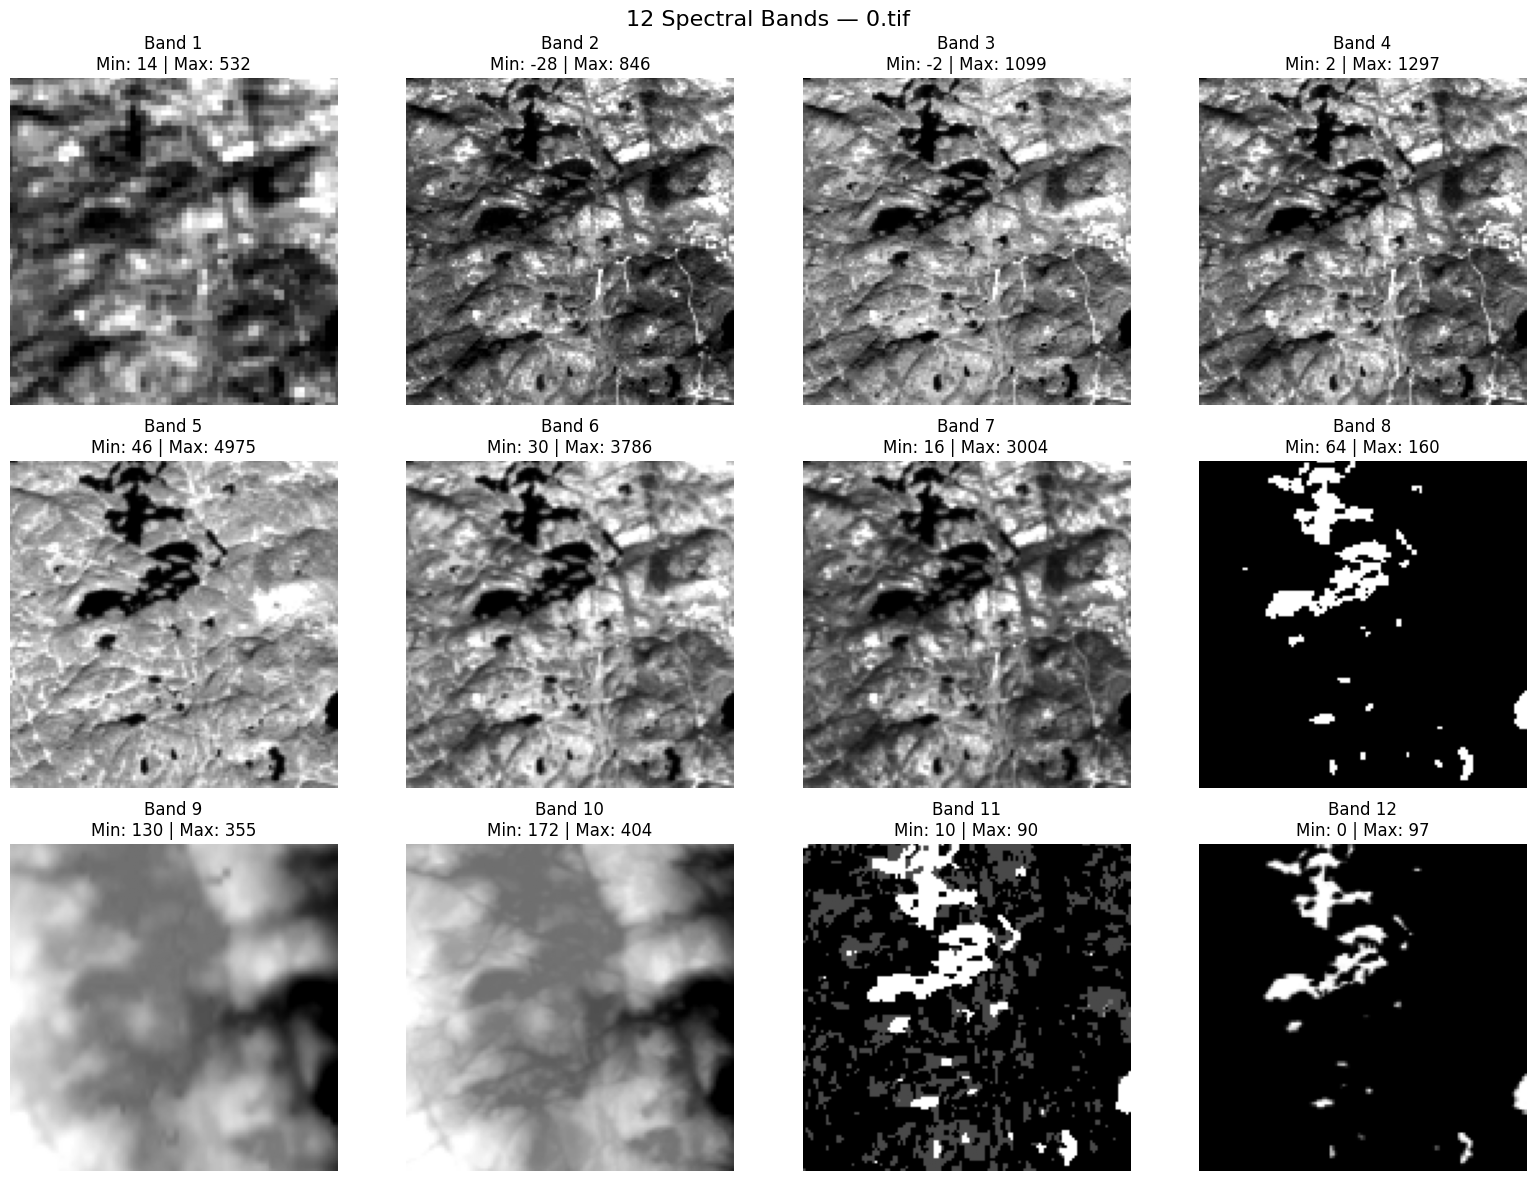

In [5]:
with rasterio.open(sample_path) as src:
    image = src.read()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, ax in enumerate(axes.flat):
    band = image[i]
    vmin, vmax = np.percentile(band, (2, 98))
    ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"Band {i+1}\nMin: {band.min()} | Max: {band.max()}")
    ax.axis("off")

plt.suptitle(f"12 Spectral Bands — {sample_path.name}", fontsize=16)
plt.tight_layout()
plt.show()

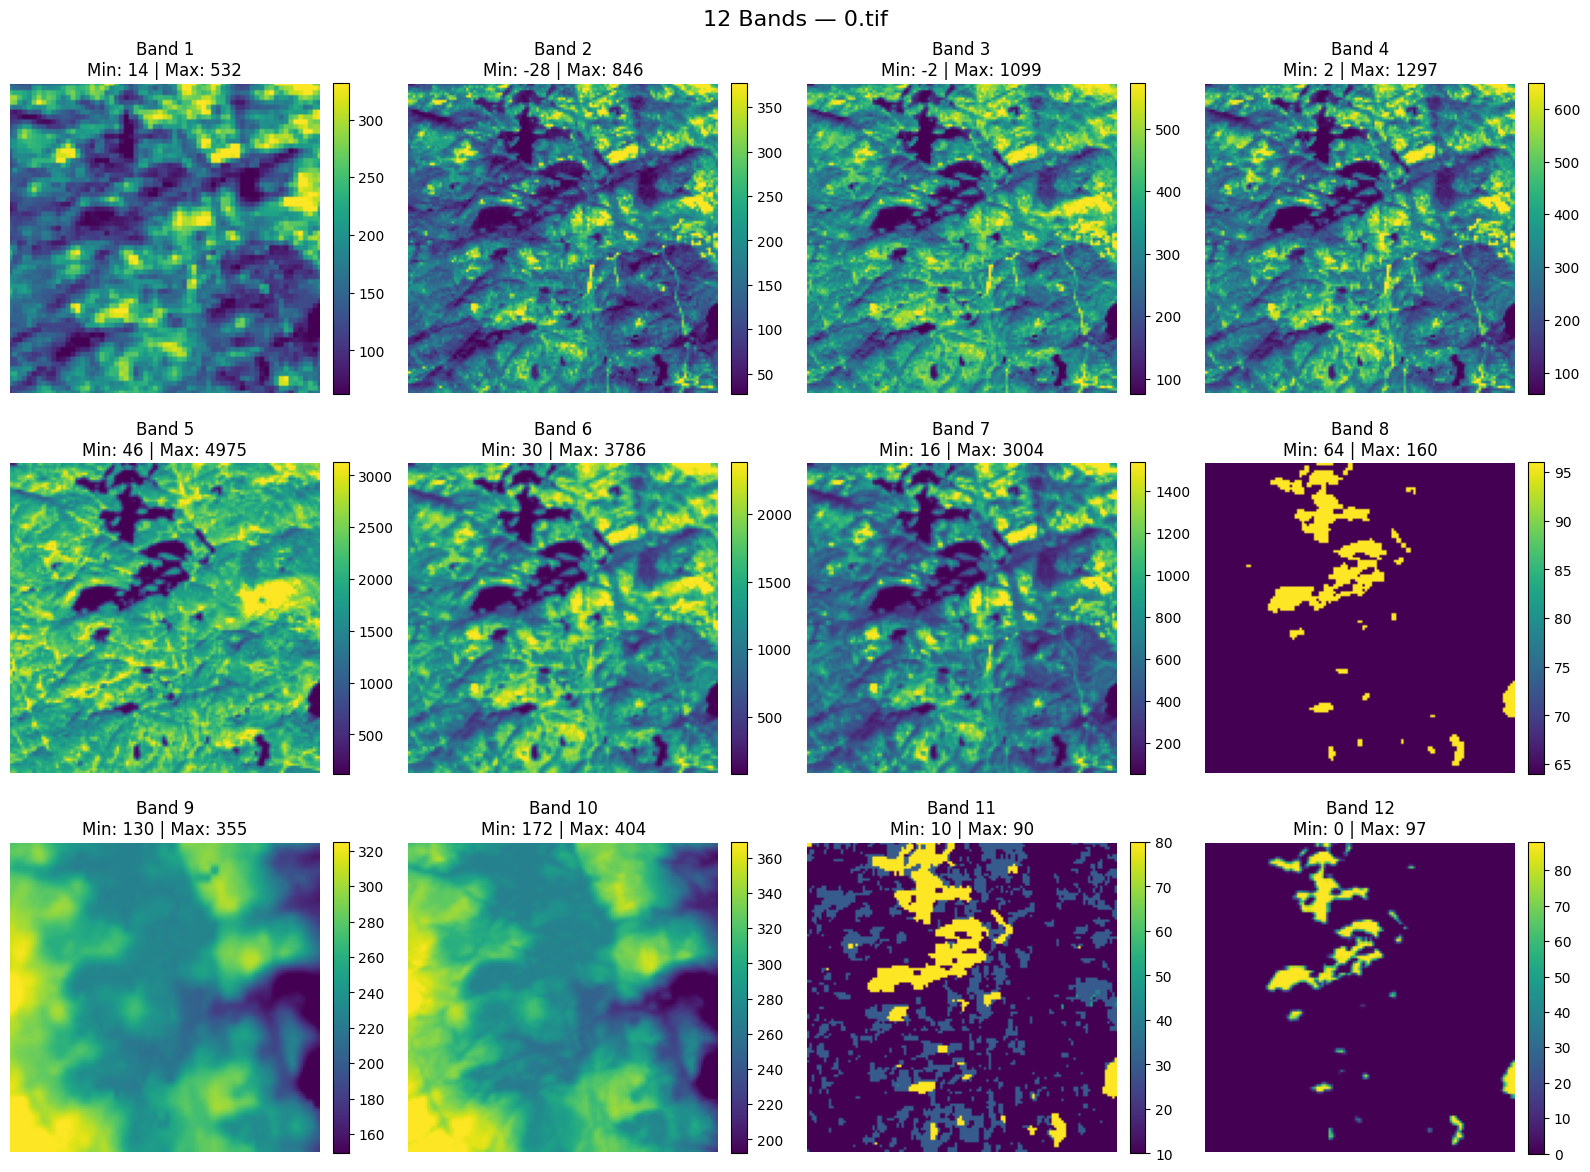

In [6]:
with rasterio.open(sample_path) as src:
    image = src.read()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, ax in enumerate(axes.flat):

    band = image[i]

    vmin, vmax = np.percentile(band, (2, 98))

    im = ax.imshow(
        band,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f"Band {i+1}\nMin: {band.min()} | Max: {band.max()}"
    )

    ax.axis("off")

    # Colorbar لكل Band
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"12 Bands — {sample_path.name}",
    fontsize=16
)

plt.tight_layout()
plt.show()

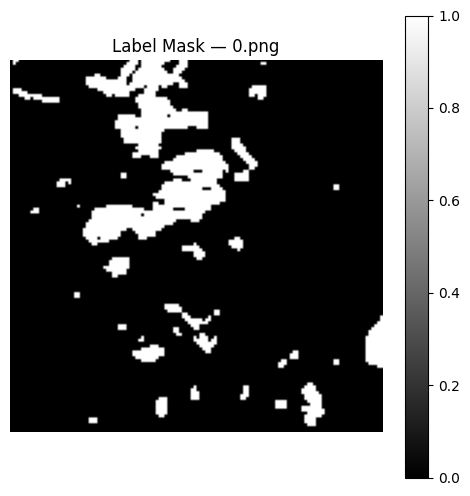

In [7]:
label_path = LABELS_DIR / f"{sample_path.stem}.png"

if label_path.exists():
    mask = np.array(Image.open(label_path))
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")
    plt.title(f"Label Mask — {label_path.name}")
    plt.colorbar()
    plt.axis("off")
    plt.show()
else:
    print("No matching label found for:", sample_path.name)

Shape: (12, 128, 128)


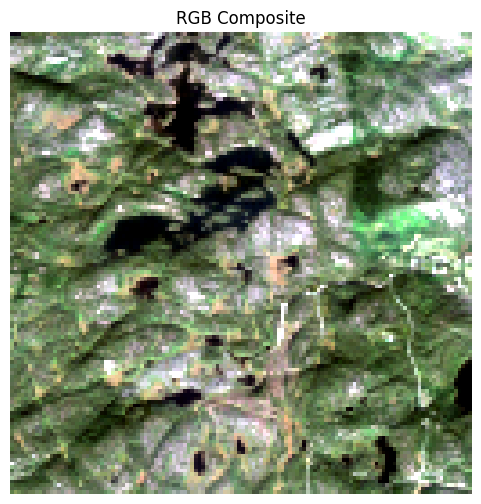

In [8]:
with rasterio.open(sample_path) as src:
    image = src.read()

print("Shape:", image.shape)

# RGB: Red=Band 4, Green=Band 3, Blue=Band 2
rgb = np.stack([
    image[3],  # Red
    image[2],  # Green
    image[1]   # Blue
], axis=-1)

# Normalize فقط للعرض
rgb = rgb.astype(np.float32)

for i in range(3):
    band = rgb[:, :, i]
    p2, p98 = np.percentile(band, (2, 98))
    rgb[:, :, i] = np.clip((band - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title("RGB Composite")
plt.axis("off")
plt.show()

In [9]:
CSV_PATH = IMAGES_DIR.parent / "channel_statistics.csv"

records = []

for image_path in sorted(IMAGES_DIR.glob("*.tif")):
    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float64)

    record = {"filename": image_path.name}

    for i in range(image.shape[0]):
        band = image[i]

        # Ignore NaN and Inf values
        valid = band[np.isfinite(band)]

        if valid.size > 0:
            record[f"min_{i+1}"] = valid.min()
            record[f"max_{i+1}"] = valid.max()
        else:
            record[f"min_{i+1}"] = np.nan
            record[f"max_{i+1}"] = np.nan

    records.append(record)

df = pd.DataFrame(records)

# Save CSV without modifying original images
df.to_csv(CSV_PATH, index=False)

print(f"Images processed: {len(df)}")
print(f"CSV saved to: {CSV_PATH}")

Images processed: 306
CSV saved to: /content/drive/MyDrive/Cellula/WaterSegmentation/data/channel_statistics.csv


In [10]:
# 1. Display first rows
display(df.head())

,filename,min_1,max_1,min_2,max_2,min_3,max_3,min_4,max_4,min_5,...,min_8,max_8,min_9,max_9,min_10,max_10,min_11,max_11,min_12,max_12
0,0.tif,14.0,532.0,-28.0,846.0,-2.0,1099.0,2.0,1297.0,46.0,...,64.0,160.0,130.0,355.0,172.0,404.0,10.0,90.0,0.0,97.0
1,1.tif,104.0,572.0,23.0,923.0,124.0,1165.0,44.0,1275.0,719.0,...,64.0,192.0,306.0,563.0,353.0,626.0,10.0,80.0,0.0,38.0
2,10.tif,-83.0,773.0,-103.0,830.0,-14.0,1109.0,-10.0,1827.0,-131.0,...,64.0,224.0,176.0,187.0,157.0,180.0,10.0,90.0,0.0,94.0
3,100.tif,-216.0,1797.0,-43.0,1987.0,229.0,2456.0,120.0,2929.0,-33.0,...,64.0,192.0,112.0,122.0,107.0,138.0,10.0,90.0,0.0,96.0
4,101.tif,67.0,838.0,76.0,1444.0,279.0,1802.0,206.0,2037.0,1601.0,...,64.0,128.0,282.0,1025.0,327.0,1078.0,10.0,60.0,0.0,0.0


In [11]:
summary = []

for i in range(1, 13):
    summary.append({
        "channel": i,
        "global_min": df[f"min_{i}"].min(),
        "global_max": df[f"max_{i}"].max(),
        "mean_min": df[f"min_{i}"].mean(),
        "mean_max": df[f"max_{i}"].mean(),
        "median_min": df[f"min_{i}"].median(),
        "median_max": df[f"max_{i}"].median()
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,channel,global_min,global_max,mean_min,mean_max,median_min,median_max
0,1,-1393.0,6568.0,-69.532680,1699.637255,-23.0,1235.0
1,2,-1169.0,9659.0,-12.862745,2492.588235,13.5,2240.0
2,3,-722.0,11368.0,215.150327,2976.843137,200.0,2674.0
3,4,-684.0,12041.0,210.127451,3312.274510,177.0,3091.0
4,5,-412.0,15841.0,362.336601,4821.660131,183.5,4771.0
5,6,-335.0,15252.0,280.578431,4428.477124,47.5,4240.0
6,7,-258.0,14647.0,191.967320,3821.660131,40.0,3564.5
7,8,64.0,255.0,68.705882,206.065359,64.0,224.0
8,9,-9999.0,4245.0,25.872549,261.908497,112.0,146.0
9,10,8.0,4287.0,254.977124,373.140523,107.0,165.0


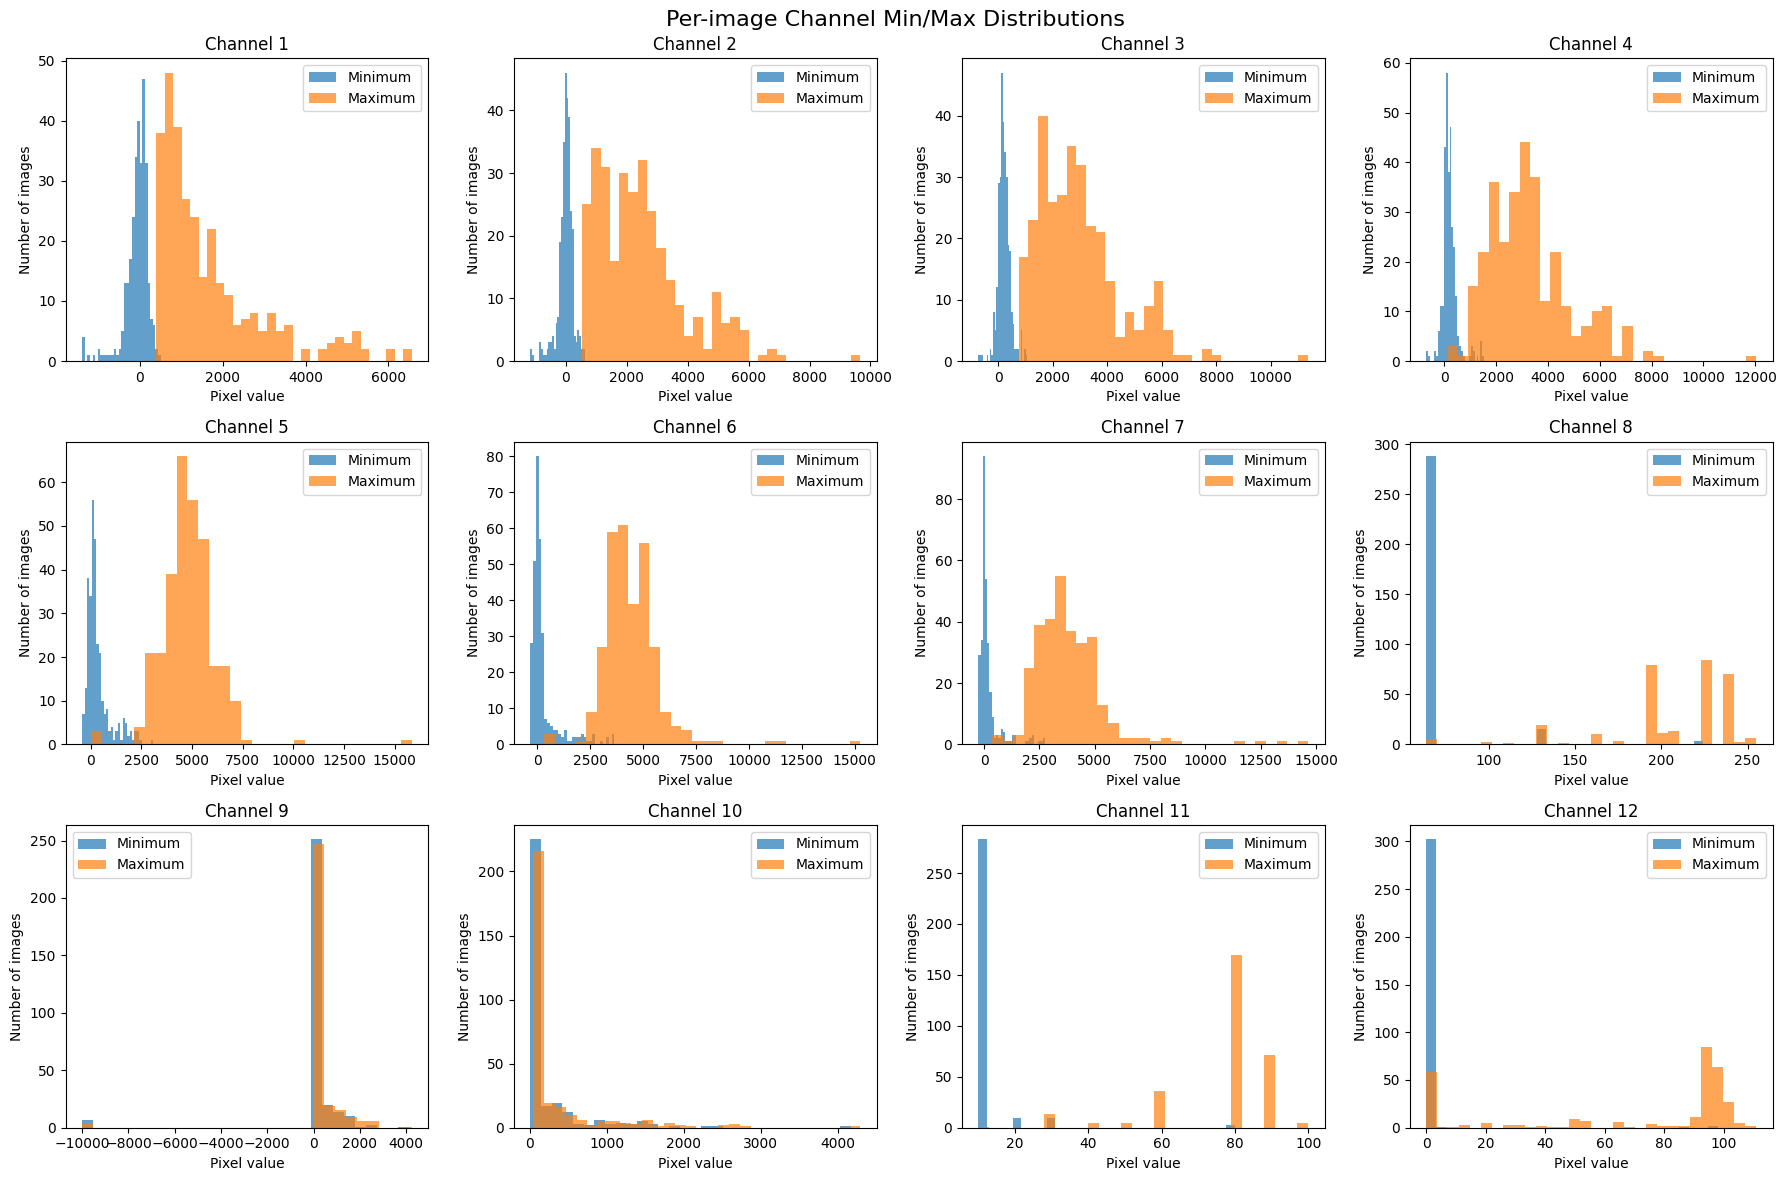

In [12]:
# 3. Histograms of per-image minimums and maximums
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for i, ax in enumerate(axes.flat, start=1):
    ax.hist(df[f"min_{i}"].dropna(), bins=30, alpha=0.7,
            label="Minimum")
    ax.hist(df[f"max_{i}"].dropna(), bins=30, alpha=0.7,
            label="Maximum")

    ax.set_title(f"Channel {i}")
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Number of images")
    ax.legend()

plt.suptitle("Per-image Channel Min/Max Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
CSV_PATH = LABELS_DIR.parent / "mask_statistics.csv"

records = []
unexpected_values = {}

for mask_path in sorted(LABELS_DIR.iterdir()):

    if not mask_path.is_file():
        continue

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    # Check unique values
    unique_values = np.unique(mask)

    unexpected = unique_values[~np.isin(unique_values, [0, 1])]

    if len(unexpected) > 0:
        unexpected_values[mask_path.name] = unexpected.tolist()

    # Count only valid binary values
    water_pixels = np.sum(mask == 1)
    background_pixels = np.sum(mask == 0)

    total_pixels = mask.size
    water_percentage = (water_pixels / total_pixels) * 100

    records.append({
        "filename": mask_path.name,
        "water_pixels": water_pixels,
        "background_pixels": background_pixels,
        "water_percentage": water_percentage
    })

mask_df = pd.DataFrame(records)

# Save CSV
mask_df.to_csv(CSV_PATH, index=False)

print(f"Total masks: {len(mask_df)}")
print(f"CSV saved to: {CSV_PATH}")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Total masks: 306
CSV saved to: /content/drive/MyDrive/Cellula/WaterSegmentation/data/mask_statistics.csv


In [14]:
with_water = mask_df[mask_df["water_pixels"] > 0]
without_water = mask_df[mask_df["water_pixels"] == 0]

print("Images containing water:", len(with_water))
print("Images with no water:", len(without_water))

Images containing water: 261
Images with no water: 45


In [15]:
if unexpected_values:
    print("Unexpected values found:")

    for filename, values in unexpected_values.items():
        print(filename, "->", values)
else:
    print("All masks contain only 0 and 1.")

All masks contain only 0 and 1.


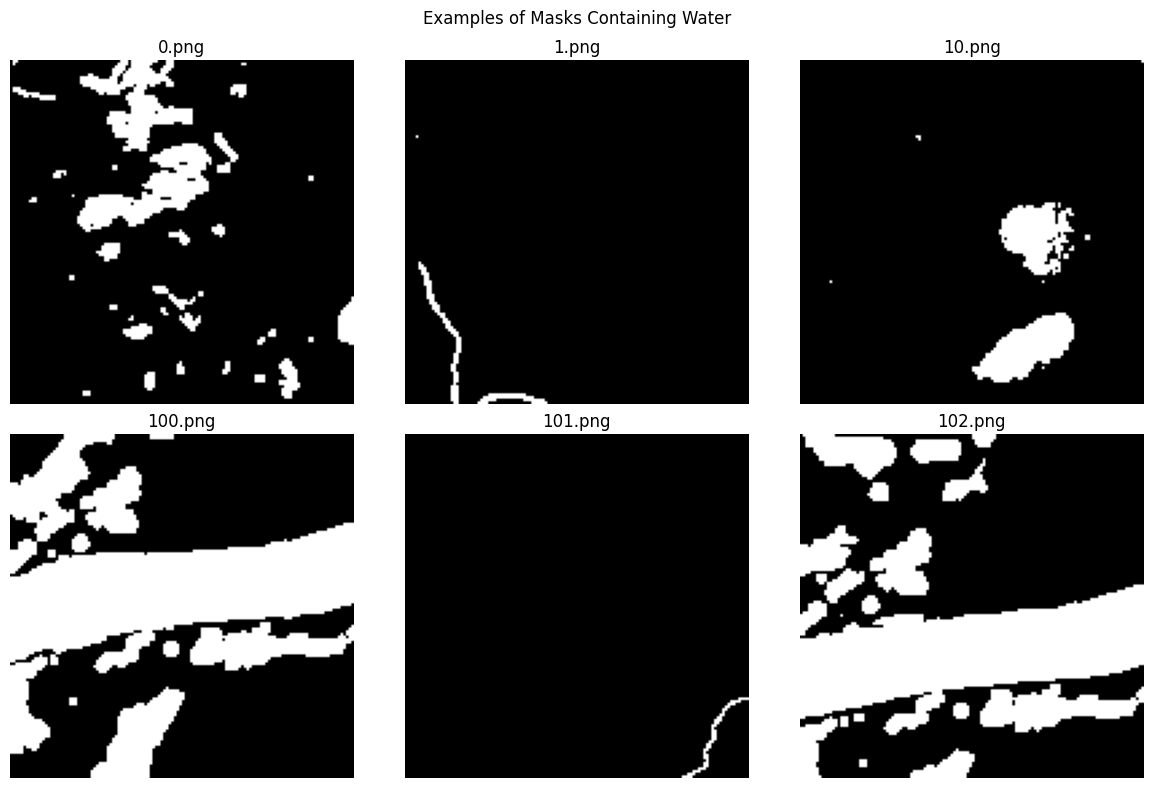

In [16]:
water_examples = with_water.head(6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, filename in zip(axes.flat, water_examples["filename"]):

    mask_path = LABELS_DIR / filename

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    ax.imshow(mask, cmap="gray")
    ax.set_title(filename)
    ax.axis("off")

plt.suptitle("Examples of Masks Containing Water")
plt.tight_layout()
plt.show()

In [17]:
total_water = mask_df["water_pixels"].sum()
total_background = mask_df["background_pixels"].sum()

total_pixels = total_water + total_background

print(f"Total water pixels: {total_water:,}")
print(f"Total background pixels: {total_background:,}")
print(f"Total pixels: {total_pixels:,}")

print(f"Water percentage: {(total_water / total_pixels) * 100:.2f}%")
print(f"Background percentage: {(total_background / total_pixels) * 100:.2f}%")

Total water pixels: 1,302,272
Total background pixels: 3,711,232
Total pixels: 5,013,504
Water percentage: 25.98%
Background percentage: 74.02%


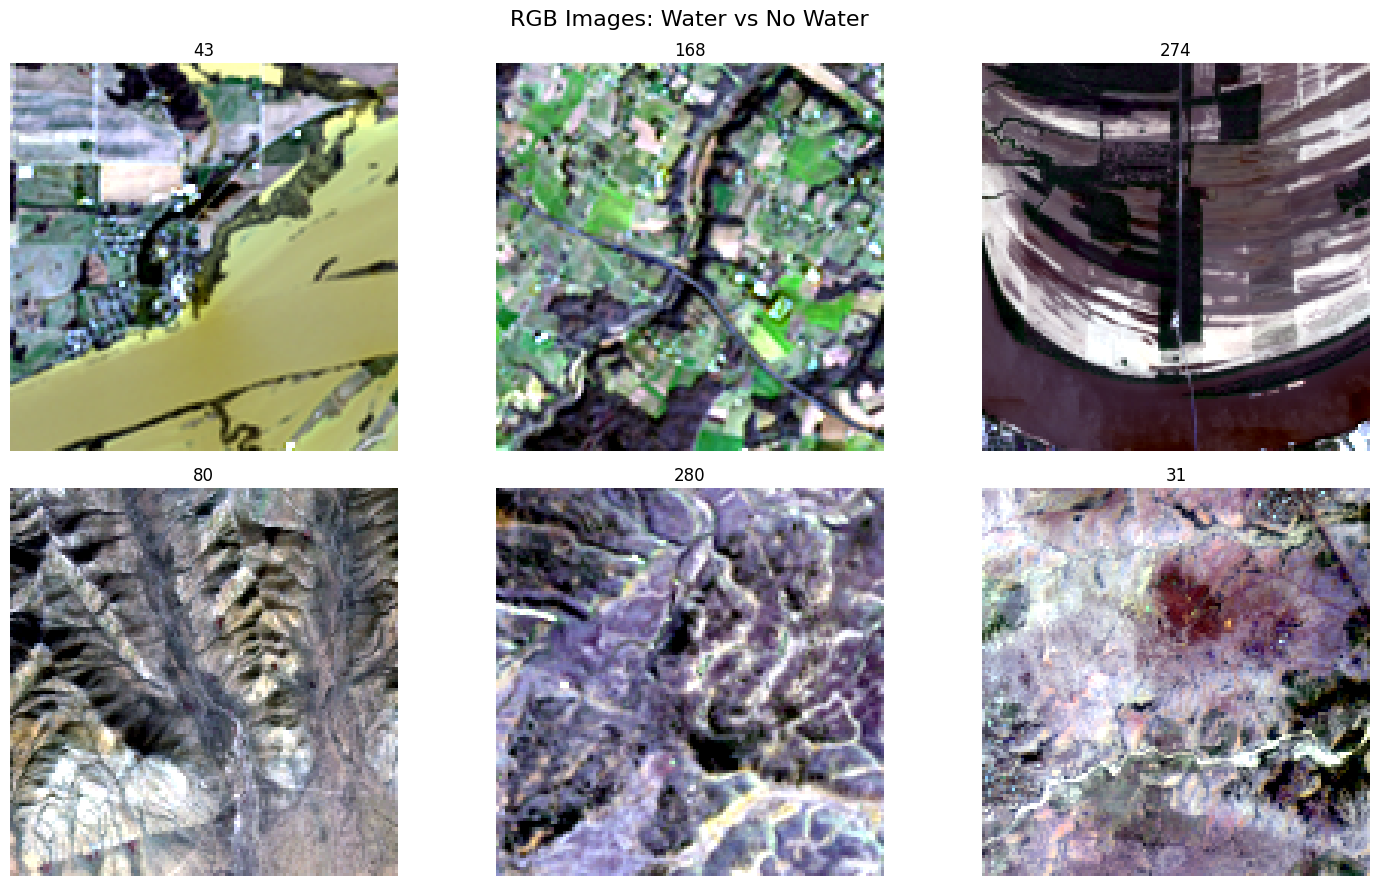

In [18]:
water_images = []
no_water_images = []

# Find matching image + mask pairs
for label_path in LABELS_DIR.glob("*.png"):

    image_path = IMAGES_DIR / f"{label_path.stem}.tif"

    if not image_path.exists():
        image_path = IMAGES_DIR / f"{label_path.stem}.TIF"

    if not image_path.exists():
        continue

    with rasterio.open(label_path) as src:
        mask = src.read(1)

    if np.any(mask == 1):
        water_images.append(image_path)
    else:
        no_water_images.append(image_path)

# Take 3 from each
selected = water_images[:3] + no_water_images[:3]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, image_path in zip(axes.flat, selected):

    with rasterio.open(image_path) as src:
        img = src.read()

    # RGB = Red(4), Green(3), Blue(2)
    rgb = np.stack([
        img[3],  # Red
        img[2],  # Green
        img[1]   # Blue
    ], axis=-1).astype(np.float32)

    # Normalize only for visualization
    for c in range(3):
        p2, p98 = np.percentile(rgb[:, :, c], (2, 98))
        rgb[:, :, c] = np.clip(
            (rgb[:, :, c] - p2) / (p98 - p2 + 1e-8),
            0, 1
        )

    ax.imshow(rgb)
    ax.set_title(image_path.stem)
    ax.axis("off")

axes[0, 0].set_ylabel("WITH WATER", fontsize=14)
axes[1, 0].set_ylabel("NO WATER", fontsize=14)

plt.suptitle("RGB Images: Water vs No Water", fontsize=16)
plt.tight_layout()
plt.show()

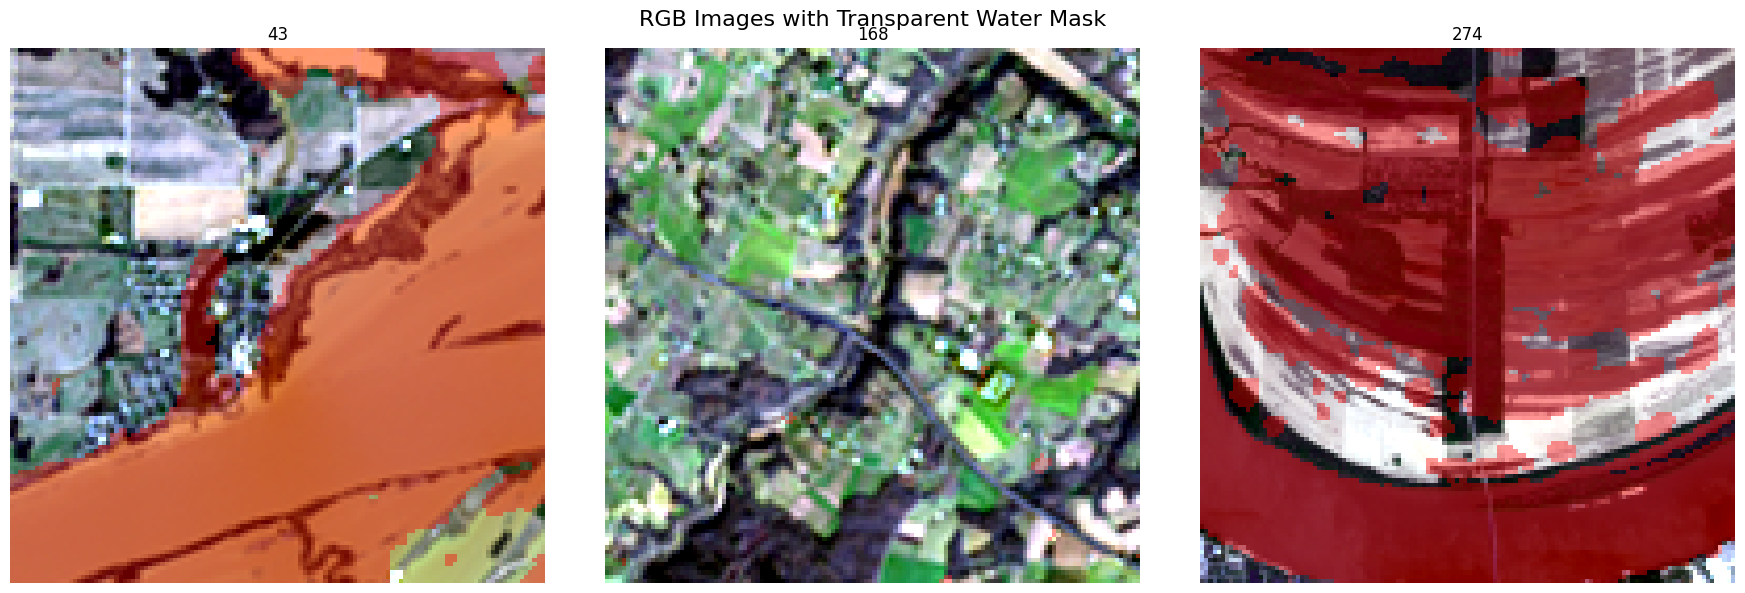

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, image_path in zip(axes, water_images[:3]):

    # Read RGB
    with rasterio.open(image_path) as src:
        img = src.read()

    rgb = np.stack([
        img[3],  # Red - Channel 4
        img[2],  # Green - Channel 3
        img[1]   # Blue - Channel 2
    ], axis=-1).astype(np.float32)

    # Visualization normalization
    for c in range(3):
        p2, p98 = np.percentile(rgb[:, :, c], (2, 98))
        rgb[:, :, c] = np.clip(
            (rgb[:, :, c] - p2) / (p98 - p2 + 1e-8),
            0, 1
        )

    # Read mask
    label_path = LABELS_DIR / f"{image_path.stem}.png"

    with rasterio.open(label_path) as src:
        mask = src.read(1)

    ax.imshow(rgb)

    # Transparent mask overlay
    # Water = 1
    ax.imshow(
        np.ma.masked_where(mask == 0, mask),
        cmap="autumn",
        alpha=0.4
    )

    ax.set_title(f"{image_path.stem}")
    ax.axis("off")

plt.suptitle("RGB Images with Transparent Water Mask", fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
# 70 images WITH water + 30 images WITHOUT water
selected_images = water_images + no_water_images

print("Total images:", len(selected_images))
print("With water:", len(water_images))
print("Without water:", len(no_water_images))


all_data = []

for image_path in selected_images:

    with rasterio.open(image_path) as src:
        img = src.read().astype(np.float32)  # (12, H, W)

    # (H, W, 12) -> (H*W, 12)
    pixels = img.transpose(1, 2, 0).reshape(-1, 12)

    # Remove pixels containing NaN / Inf
    pixels = pixels[np.all(np.isfinite(pixels), axis=1)]

    all_data.append(pixels)

# Combine all selected images
all_data = np.vstack(all_data)

# Create DataFrame
channel_names = [
    "Coastal Aerosol",
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "QA Band",
    "Merit DEM",
    "Copernicus DEM",
    "WorldCover",
    "Water Occurrence"
]

df_corr = pd.DataFrame(all_data, columns=channel_names)

print("DataFrame shape:", df_corr.shape)
display(df_corr.head())

Total images: 306
With water: 261
Without water: 45
DataFrame shape: (5013504, 12)


,Coastal Aerosol,Blue,Green,Red,NIR,SWIR1,SWIR2,QA Band,Merit DEM,Copernicus DEM,WorldCover,Water Occurrence
0,512.0,597.0,865.0,1083.0,2458.0,3129.0,2059.0,64.0,130.0,130.0,10.0,0.0
1,461.0,547.0,871.0,1018.0,2566.0,2647.0,1735.0,64.0,130.0,130.0,10.0,0.0
2,296.0,345.0,473.0,552.0,1645.0,1936.0,1249.0,64.0,130.0,132.0,10.0,0.0
3,331.0,368.0,509.0,639.0,1537.0,2202.0,1466.0,64.0,129.0,136.0,10.0,0.0
4,334.0,367.0,522.0,638.0,1646.0,2326.0,1553.0,64.0,130.0,141.0,10.0,0.0


In [21]:
CSV_PATH = IMAGES_DIR.parent /"channel_pixels_all.csv"
df_corr.to_csv(CSV_PATH, index=False)

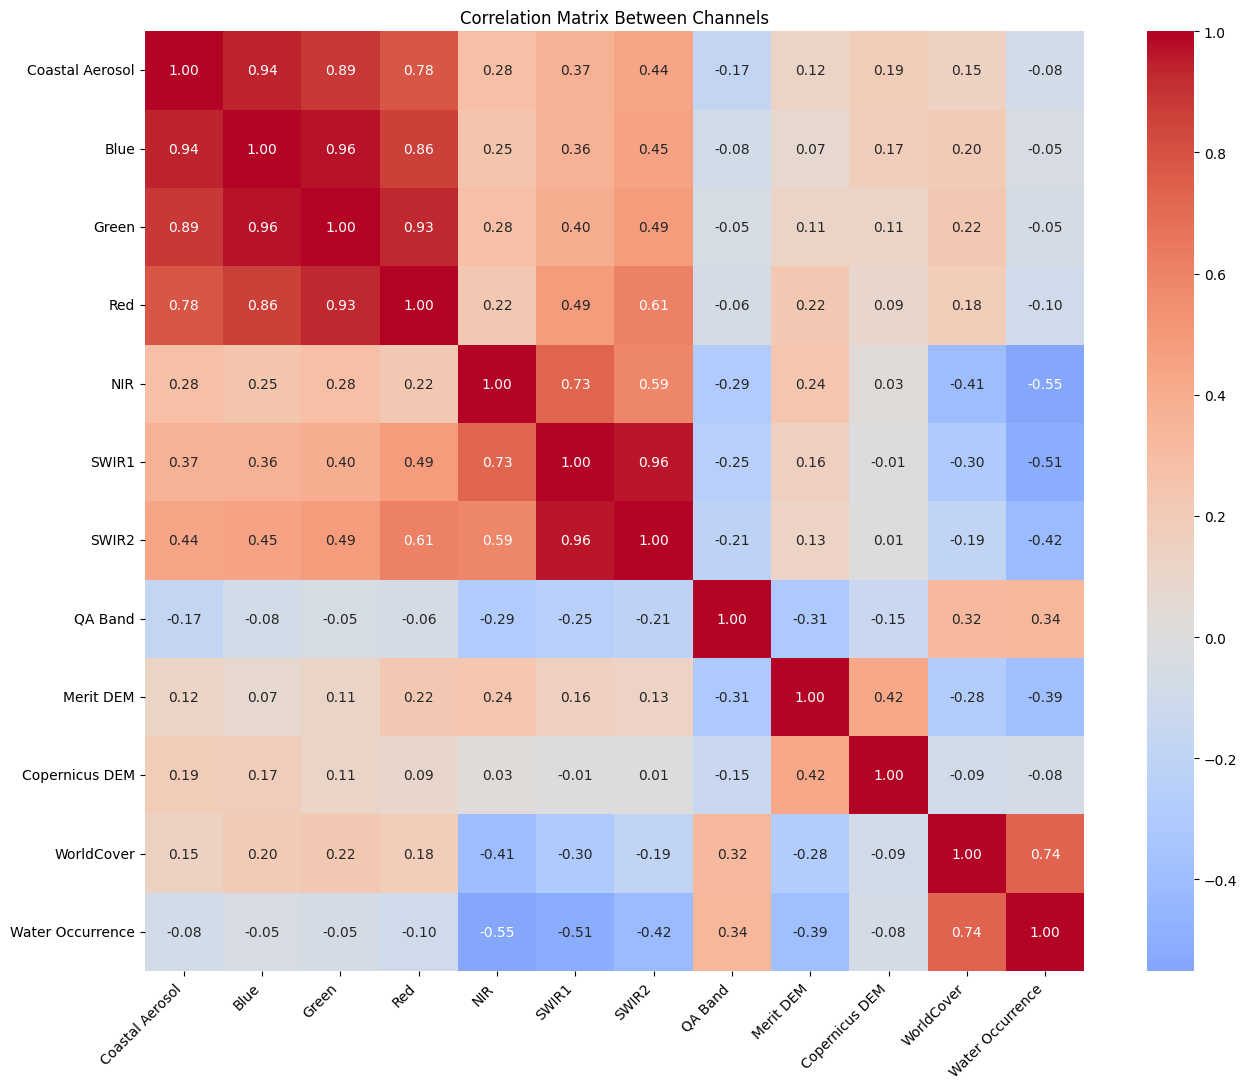

In [22]:
corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix Between Channels")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
stats = []

categorical_channels = ["QA Band", "WorldCover"]

for channel in channel_names:
    values = df_corr[channel].dropna()

    stats.append({
        "Channel": channel,
        "Mean": values.mean(),
        "Median": values.median(),
        "Std": values.std(),
        "Min": values.min(),
        "Max": values.max()
    })

stats_df = pd.DataFrame(stats)

display(stats_df)

,Channel,Mean,Median,Std,Min,Max
0,Coastal Aerosol,396.467773,363.0,269.085693,-1393.0,6568.0
1,Blue,494.620911,458.0,325.229309,-1169.0,9659.0
2,Green,822.319824,775.0,417.010345,-722.0,11368.0
3,Red,973.675537,904.0,585.248230,-684.0,12041.0
4,NIR,2090.110840,2164.0,1052.646362,-412.0,15841.0
5,SWIR1,1964.050415,1987.0,1187.608887,-335.0,15252.0
6,SWIR2,1351.273926,1251.0,960.347778,-258.0,14647.0
7,QA Band,102.739601,64.0,48.237431,64.0,255.0
8,Merit DEM,141.803925,119.0,1360.733887,-9999.0,4245.0
9,Copernicus DEM,300.741425,119.0,495.430756,8.0,4287.0


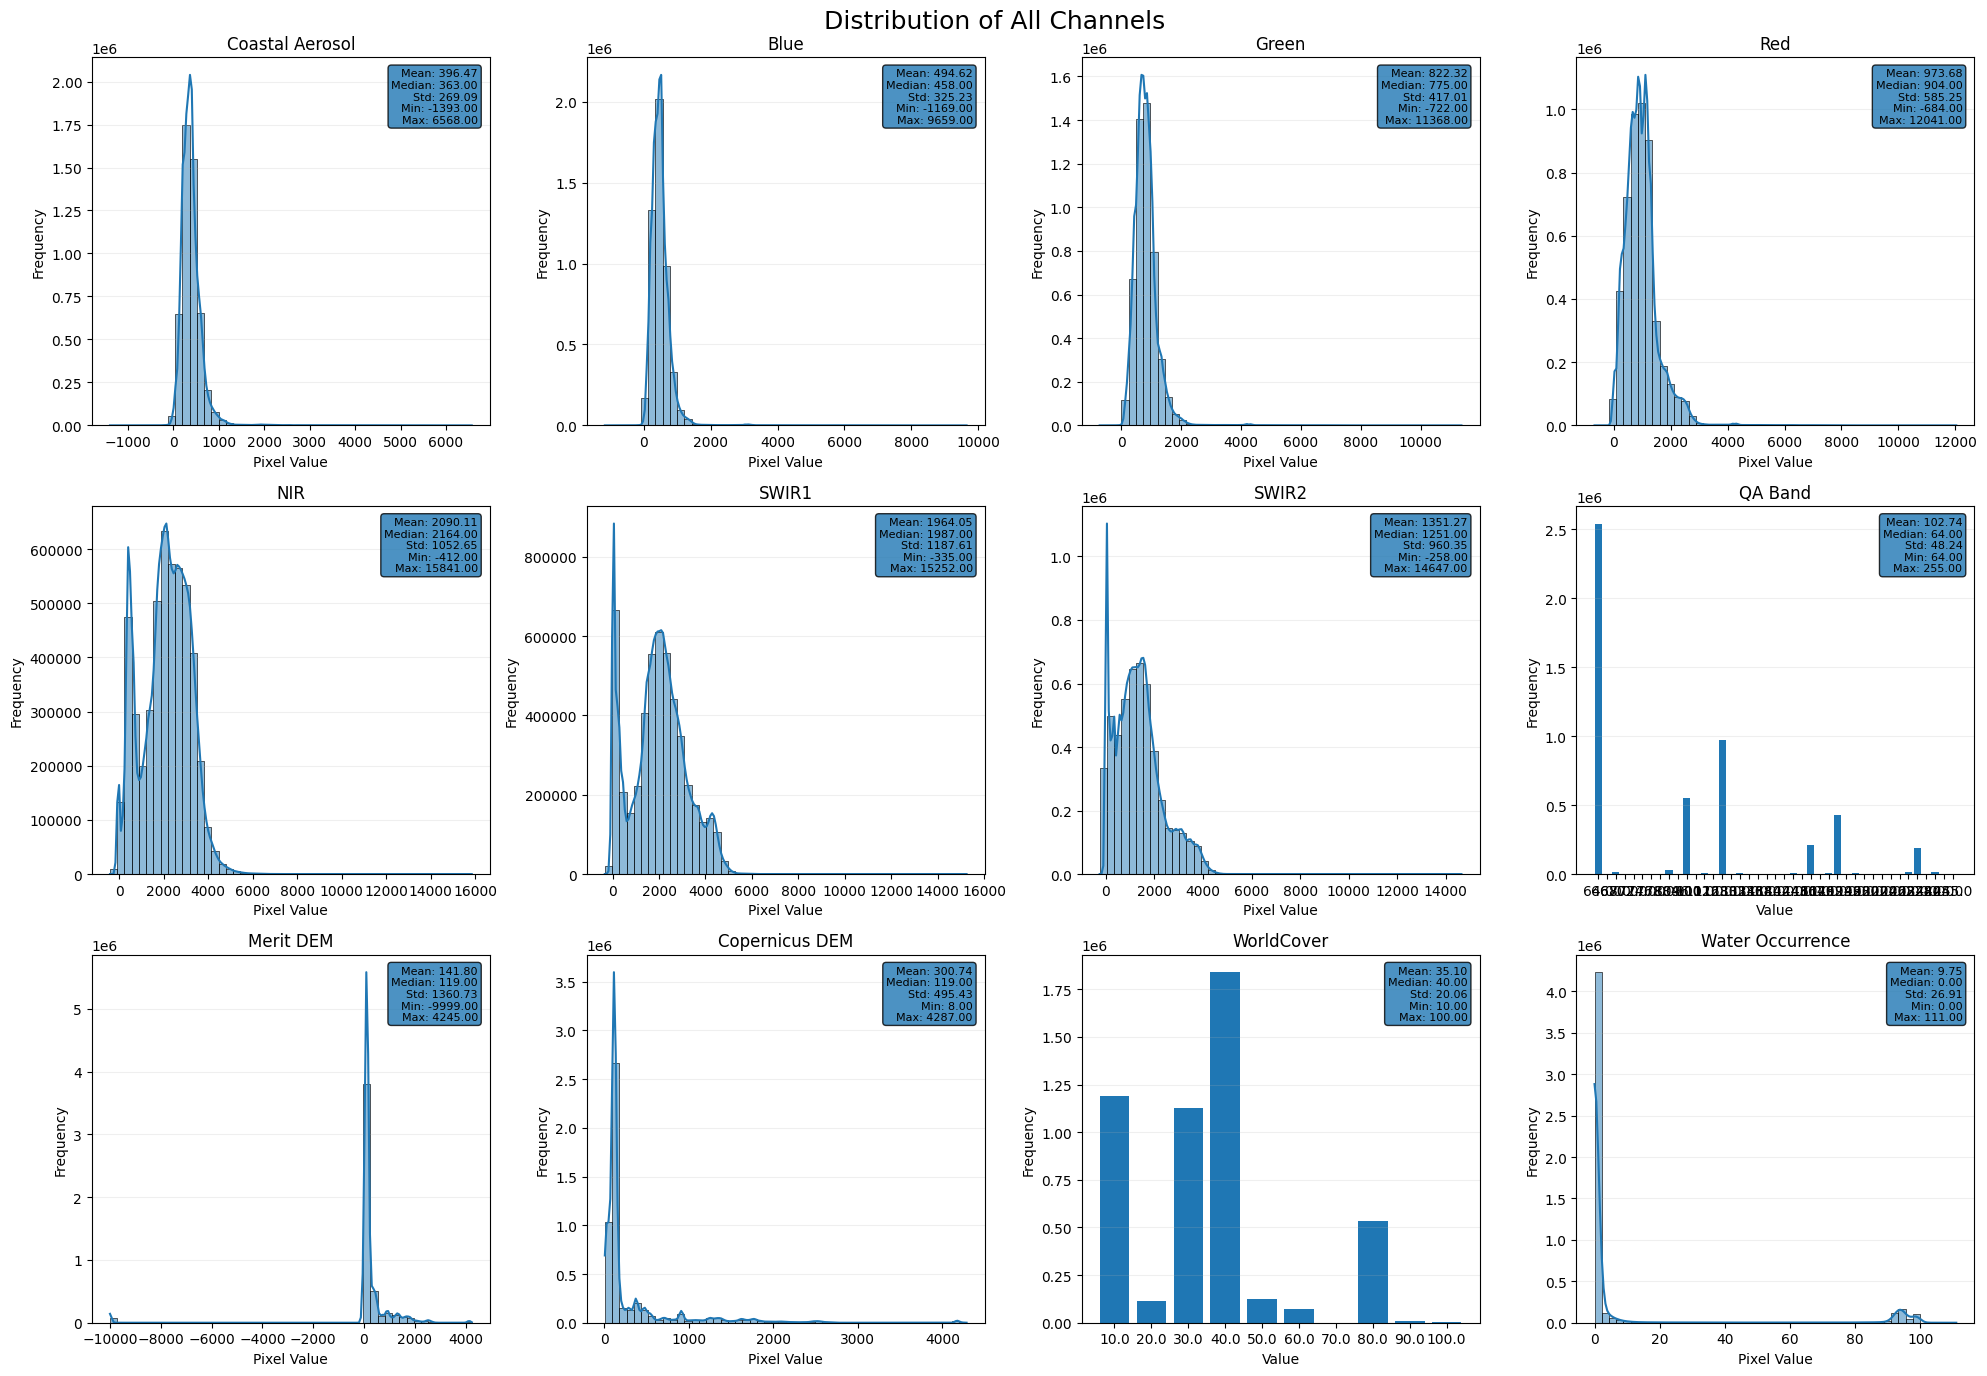

In [24]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for channel, ax in zip(channel_names, axes.flat):

    values = df_corr[channel].dropna()

    if channel in categorical_channels:

        # Categorical → frequency
        counts = values.value_counts().sort_index()

        ax.bar(
            counts.index.astype(str),
            counts.values
        )

        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    else:

        # Continuous → Histogram + KDE
        sns.histplot(
            values,
            bins=50,
            kde=True,
            ax=ax
        )

        ax.set_xlabel("Pixel Value")
        ax.set_ylabel("Frequency")

    # Get statistics for current channel
    s = stats_df[stats_df["Channel"] == channel].iloc[0]

    stats_text = (
        f"Mean: {s['Mean']:.2f}\n"
        f"Median: {s['Median']:.2f}\n"
        f"Std: {s['Std']:.2f}\n"
        f"Min: {s['Min']:.2f}\n"
        f"Max: {s['Max']:.2f}"
    )

    ax.text(
        0.97, 0.97,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round", alpha=0.8)
    )

    ax.set_title(channel)
    ax.grid(axis="y", alpha=0.2)

plt.suptitle("Distribution of All Channels", fontsize=18)
plt.tight_layout()
plt.show()

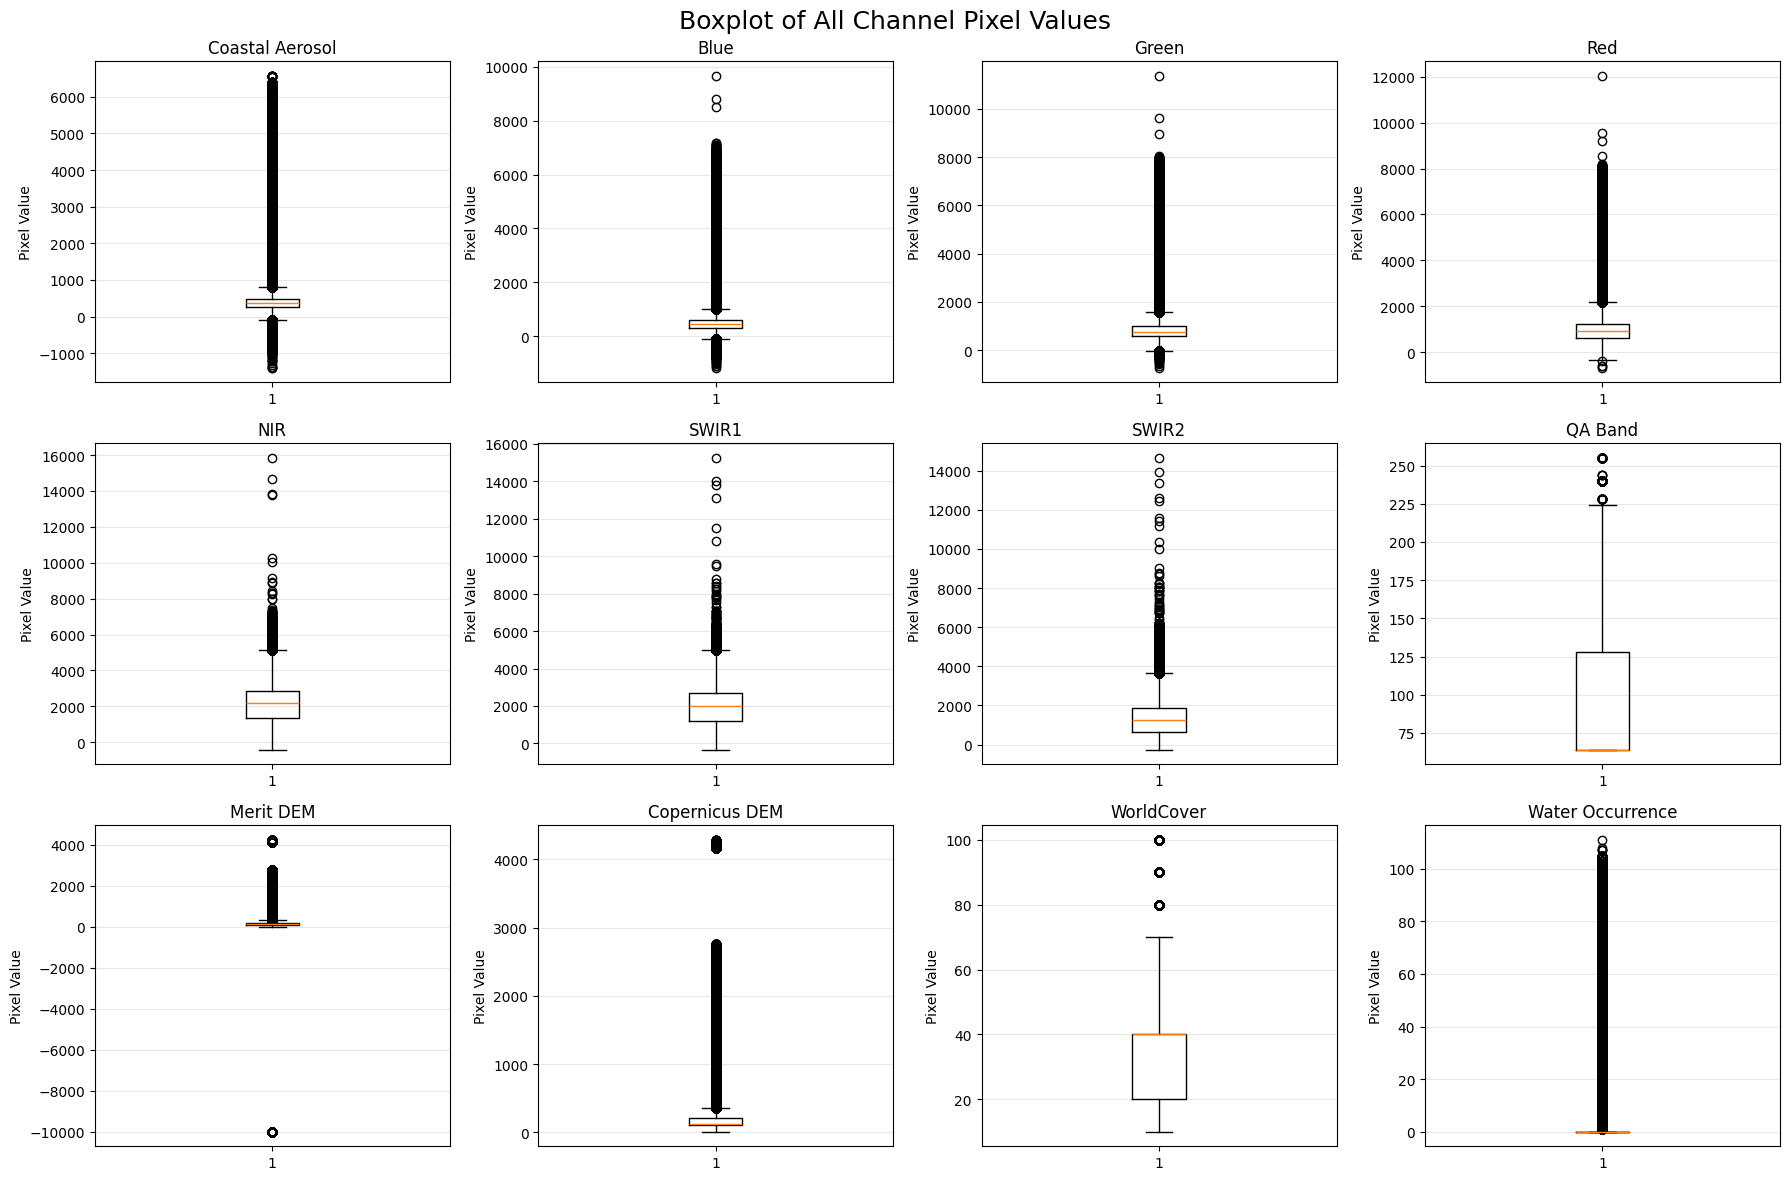

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for channel, ax in zip(channel_names, axes.flat):

    values = df_corr[channel].dropna()

    ax.boxplot(values)

    ax.set_title(channel)
    ax.set_ylabel("Pixel Value")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Boxplot of All Channel Pixel Values", fontsize=18)
plt.tight_layout()
plt.show()

In [31]:
def get_values(channel):
    s = pd.to_numeric(df_corr[channel], errors="coerce")
    arr = s.to_numpy(dtype=float)
    return s, arr[np.isfinite(arr)]


def show_stats(channel):
    s, values = get_values(channel)

    stats = pd.DataFrame({
        "Metric": ["Mean", "Median", "Std", "Min", "Max"],
        "Value": [
            np.mean(values),
            np.median(values),
            np.std(values),
            np.min(values),
            np.max(values)
        ]
    })

    display(stats)


def show_quality(channel):
    s, values = get_values(channel)

    total = len(s)
    arr = s.to_numpy(dtype=float)

    non_finite = np.sum(~np.isfinite(arr))
    negative = np.sum(values < 0)
    zero = np.sum(values == 0)

    print(f"Channel: {channel}")
    print(f"Total values: {total:,}")
    print(f"Non-finite values (NaN/Inf): {non_finite:,} ({non_finite/total*100:.4f}%)")
    print(f"Negative values: {negative:,} ({negative/len(values)*100:.4f}%)")
    print(f"Zero values: {zero:,} ({zero/len(values)*100:.4f}%)")

    if channel not in categorical_channels:
        mean = np.mean(values)
        std = np.std(values)

        extreme = np.sum(np.abs(values - mean) > 3 * std)

        print(
            f"Values beyond ±3 STD: "
            f"{extreme:,} ({extreme/len(values)*100:.4f}%)"
        )

        print(
            "\nNote: Values beyond ±3 STD are flagged for inspection only; "
            "they are NOT automatically considered invalid or removed."
        )


def show_distribution(channel):
    s, values = get_values(channel)

    sample_size = min(100000, len(values))
    sample = pd.Series(values).sample(
        n=sample_size,
        random_state=42
    )

    mean = np.mean(values)
    median = np.median(values)

    plt.figure(figsize=(10, 5))

    sns.histplot(
        sample,
        bins=100,
        kde=True,
        stat="density"
    )

    plt.axvline(
        mean,
        linestyle="--",
        label=f"Mean = {mean:.4f}"
    )

    plt.axvline(
        median,
        linestyle=":",
        label=f"Median = {median:.4f}"
    )

    plt.title(f"{channel} Distribution")
    plt.xlabel(channel)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


def show_boxplot(channel):
    s, values = get_values(channel)

    sample_size = min(100000, len(values))
    sample = pd.Series(values).sample(
        n=sample_size,
        random_state=42
    )

    plt.figure(figsize=(10, 3))
    sns.boxplot(x=sample)

    plt.title(f"{channel} Boxplot")
    plt.xlabel(channel)
    plt.show()

## 1. Coastal Aerosol

The Coastal Aerosol band is a spectral band designed to capture information in the coastal/aerosol-sensitive region.

It is a continuous numerical band and may provide useful information for distinguishing water from land, atmospheric effects, and coastal surfaces.

For water segmentation, it can provide additional spectral information, although its usefulness should be determined from the data distribution and its relationship with the water mask.

In [32]:
show_stats("Coastal Aerosol")

,Metric,Value
0,Mean,396.467673
1,Median,363.000000
2,Std,270.066593
3,Min,-1393.000000
4,Max,6568.000000


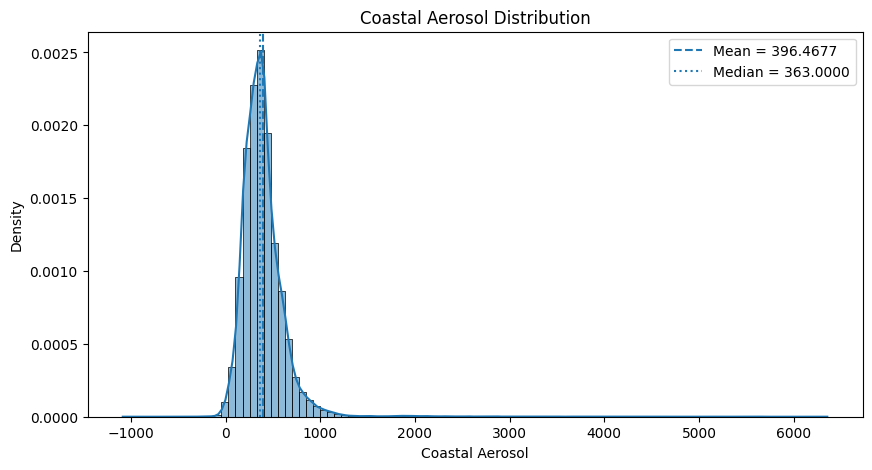

In [33]:
show_distribution("Coastal Aerosol")

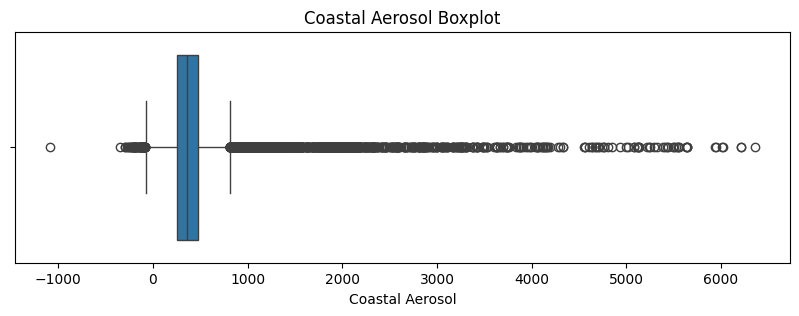

In [34]:
show_boxplot("Coastal Aerosol")

In [35]:
show_quality("Coastal Aerosol")

Channel: Coastal Aerosol
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 20,840 (0.4157%)
Zero values: 527 (0.0105%)
Values beyond ±3 STD: 39,846 (0.7948%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 2. Blue

The Blue band measures reflected energy in the blue portion of the electromagnetic spectrum.

It is a continuous spectral band and can be useful for distinguishing water from vegetation, soil, and built-up surfaces because water generally has different spectral behavior from many land surfaces.

Its distribution and range are examined without modifying the original values.

In [37]:
show_stats("Blue")

,Metric,Value
0,Mean,494.621029
1,Median,458.000000
2,Std,325.979197
3,Min,-1169.000000
4,Max,9659.000000


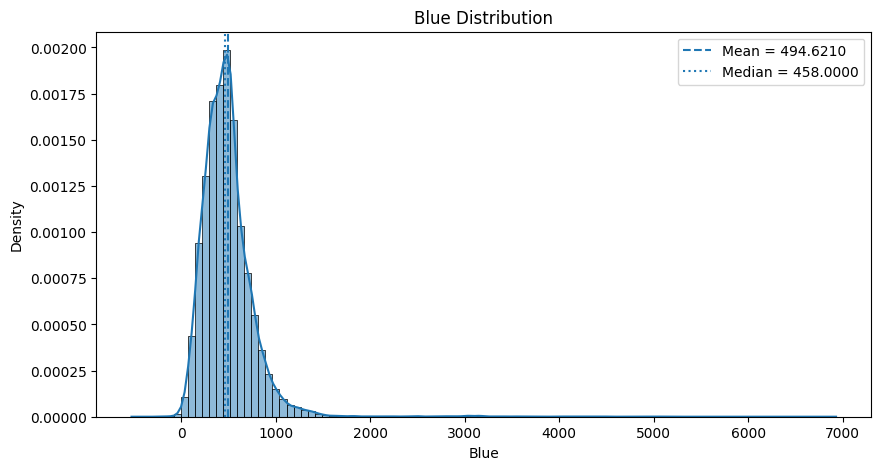

In [38]:
show_distribution("Blue")

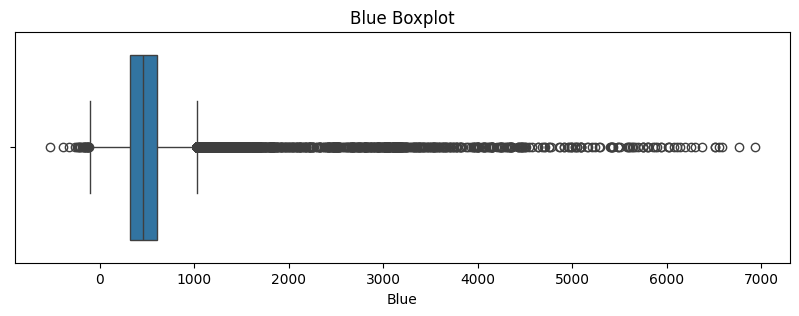

In [39]:
show_boxplot("Blue")

In [40]:
show_quality("Blue")

Channel: Blue
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 8,145 (0.1625%)
Zero values: 211 (0.0042%)
Values beyond ±3 STD: 36,763 (0.7333%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 3. Green

The Green band measures reflected energy in the green portion of the electromagnetic spectrum.

It is a continuous spectral band.

Green can help distinguish water from vegetation and other land-cover types because water and vegetation have different spectral responses in this region.

In [41]:
show_stats("Green")

,Metric,Value
0,Mean,822.319785
1,Median,775.000000
2,Std,418.121630
3,Min,-722.000000
4,Max,11368.000000


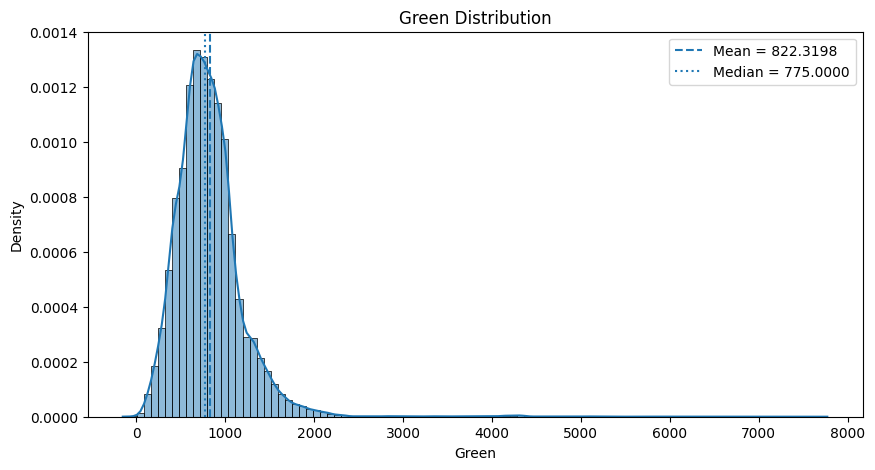

In [42]:
show_distribution("Green")

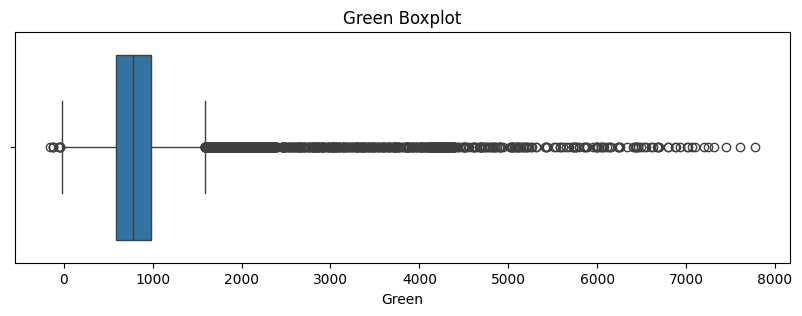

In [43]:
show_boxplot("Green")

In [44]:
show_quality("Green")

Channel: Green
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 728 (0.0145%)
Zero values: 11 (0.0002%)
Values beyond ±3 STD: 41,359 (0.8250%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 4. Red

The Red band measures reflected energy in the red portion of the electromagnetic spectrum.

It is a continuous spectral band.

Red is commonly useful for distinguishing vegetation, soil, and water because these surfaces have different spectral responses in the red region.

In [45]:
show_stats("Red")

,Metric,Value
0,Mean,973.674961
1,Median,904.000000
2,Std,586.702975
3,Min,-684.000000
4,Max,12041.000000


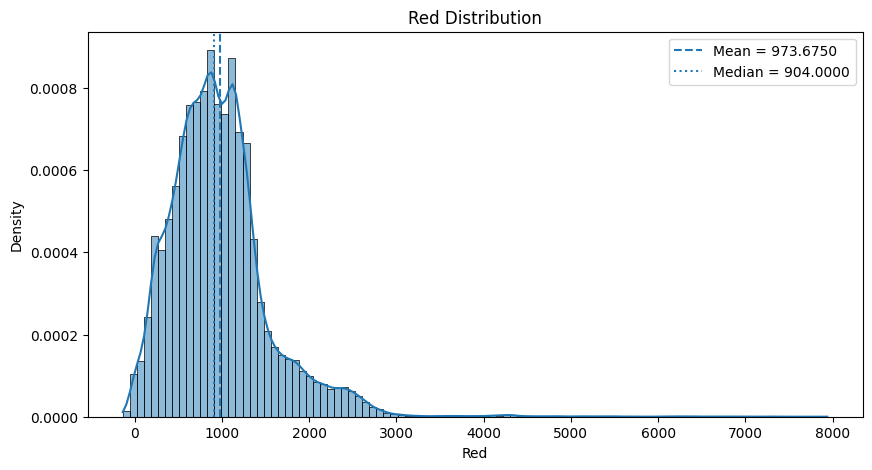

In [46]:
show_distribution("Red")

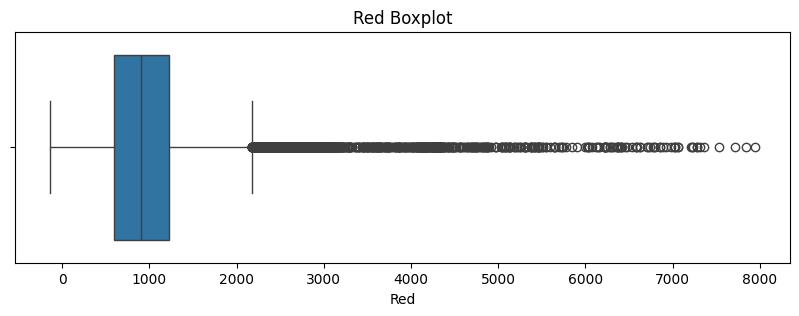

In [47]:
show_boxplot("Red")

In [48]:
show_quality("Red")

Channel: Red
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 31,146 (0.6212%)
Zero values: 665 (0.0133%)
Values beyond ±3 STD: 42,618 (0.8501%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 5. NIR

The Near Infrared (NIR) band measures reflected energy in the near-infrared region.

It is a continuous spectral band and can be particularly useful for separating water from vegetation and other land surfaces.

Water usually has a different response in NIR compared with vegetation and many terrestrial surfaces.

In [49]:
show_stats("NIR")

,Metric,Value
0,Mean,2090.110996
1,Median,2164.000000
2,Std,1055.984607
3,Min,-412.000000
4,Max,15841.000000


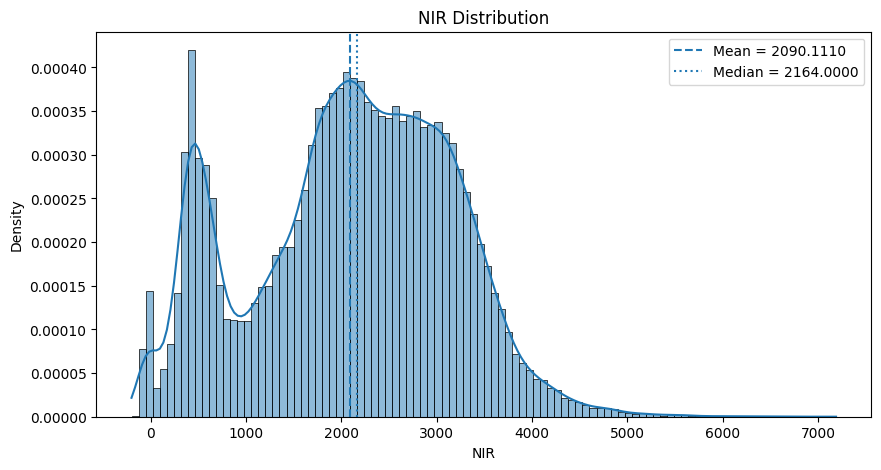

In [50]:
show_distribution("NIR")

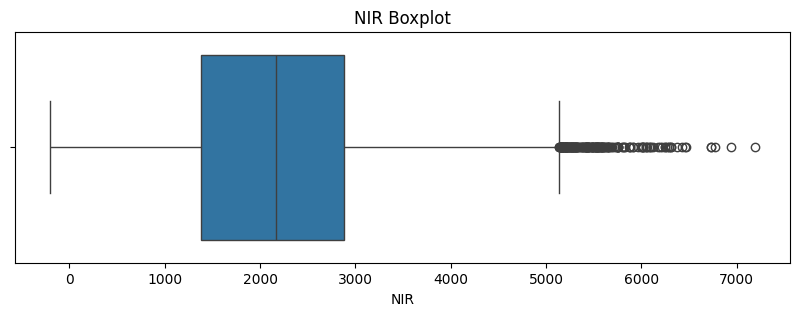

In [51]:
show_boxplot("NIR")

In [52]:
show_quality("NIR")

Channel: NIR
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 68,397 (1.3643%)
Zero values: 960 (0.0191%)
Values beyond ±3 STD: 6,828 (0.1362%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 6. SWIR1

SWIR1 (Short-Wave Infrared 1) measures reflected energy in the first short-wave infrared region.

It is a continuous spectral band.

SWIR information can be highly useful for water segmentation because water generally has strong absorption in the SWIR region, helping separate water from vegetation, soil, and built-up surfaces.

In [53]:
show_stats("SWIR1")

,Metric,Value
0,Mean,1964.050569
1,Median,1987.000000
2,Std,1191.422266
3,Min,-335.000000
4,Max,15252.000000


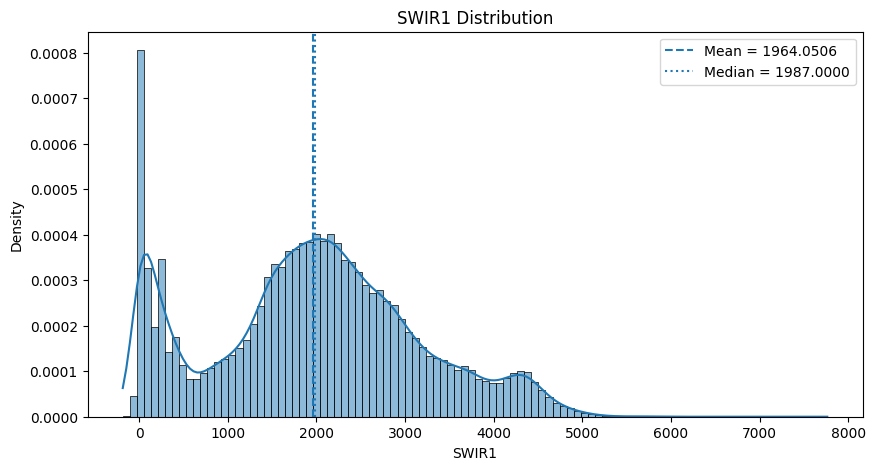

In [54]:
show_distribution("SWIR1")

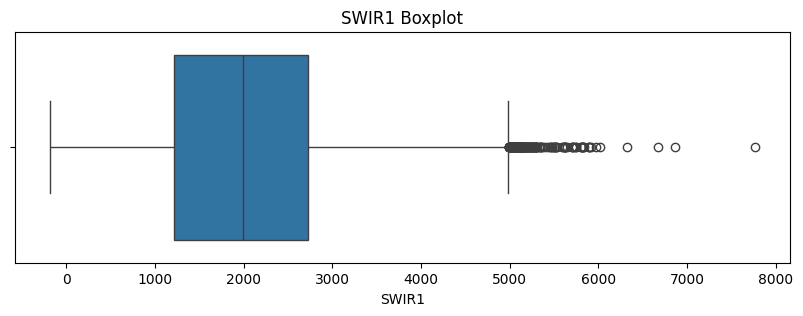

In [55]:
show_boxplot("SWIR1")

In [56]:
show_quality("SWIR1")

Channel: SWIR1
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 53,630 (1.0697%)
Zero values: 2,127 (0.0424%)
Values beyond ±3 STD: 1,528 (0.0305%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 7. SWIR2

SWIR2 (Short-Wave Infrared 2) measures reflected energy in a second short-wave infrared region.

It is a continuous spectral band.

SWIR2 can provide useful information for separating water from land surfaces because water has strong absorption in the short-wave infrared region.

In [57]:
show_stats("SWIR2")

,Metric,Value
0,Mean,1351.273953
1,Median,1251.000000
2,Std,961.762588
3,Min,-258.000000
4,Max,14647.000000


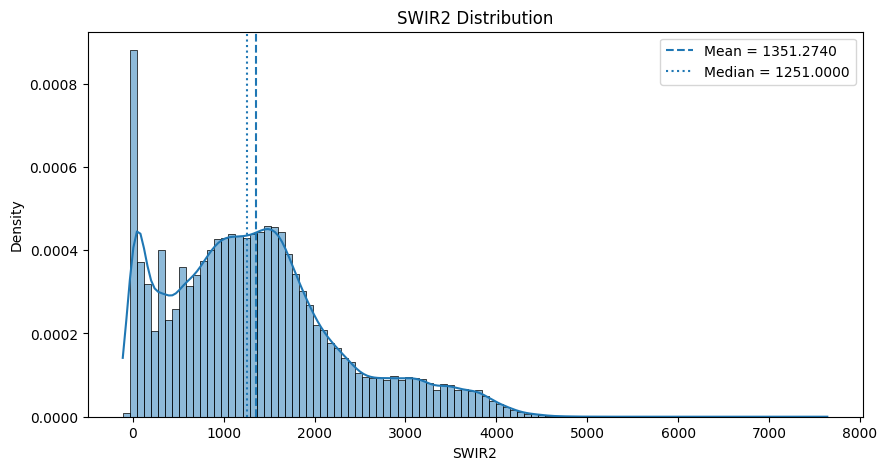

In [58]:
show_distribution("SWIR2")

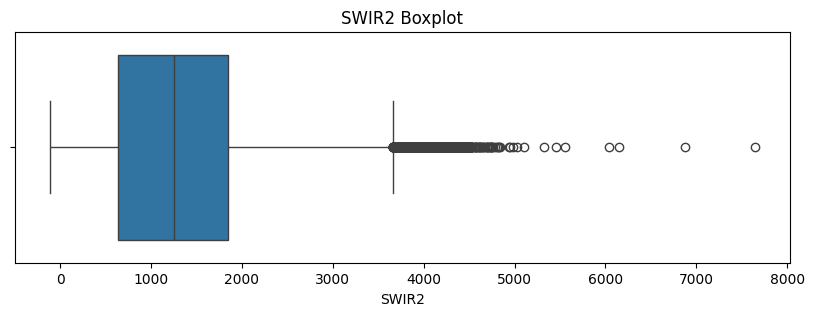

In [59]:
show_boxplot("SWIR2")

In [60]:
show_quality("SWIR2")

Channel: SWIR2
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 33,084 (0.6599%)
Zero values: 4,692 (0.0936%)
Values beyond ±3 STD: 13,177 (0.2628%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 8. QA Band

The QA (Quality Assessment) band contains quality-related information rather than ordinary continuous spectral measurements.

It may represent quality flags or bit-coded information describing the quality or condition of pixels.

Therefore, it should be treated as a quality/categorical-type feature rather than a continuous numerical feature.

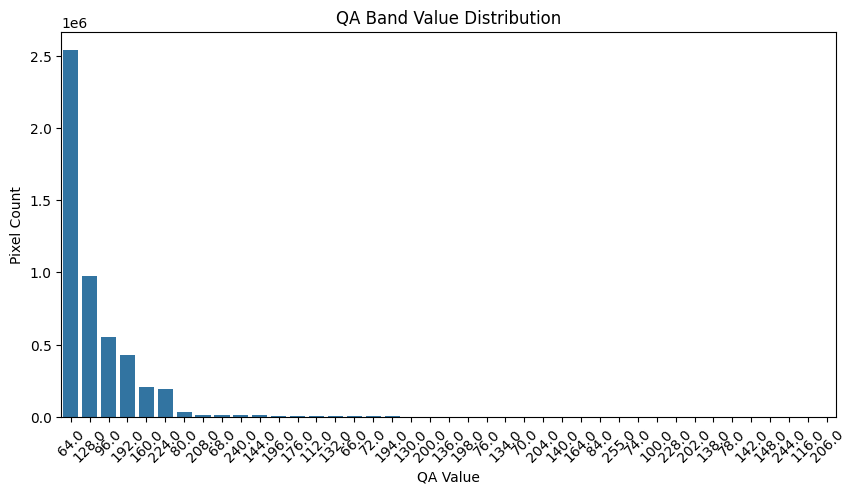

In [80]:
qa = pd.to_numeric(df_corr["QA Band"], errors="coerce").dropna()


plt.figure(figsize=(10, 5))
sns.countplot(
    x=qa.astype(str),
    order=qa.astype(str).value_counts().index
)

plt.title("QA Band Value Distribution")
plt.xlabel("QA Value")
plt.ylabel("Pixel Count")
plt.xticks(rotation=45)
plt.show()

In [67]:
qa = pd.to_numeric(df_corr["QA Band"], errors="coerce")

print("Total values:", len(qa))

print(
    "Missing values:",
    qa.isna().sum(),
    f"({qa.isna().mean()*100:.4f}%)"
)

print("\nUnique values:")
display(qa.value_counts(dropna=False).sort_index())

Total values: 5013504
Missing values: 0 (0.0000%)

Unique values:


,count
QA Band,
64.0,2539819
66.0,2994
68.0,11739
70.0,429
72.0,2465
74.0,51
76.0,580
78.0,9
80.0,31807


## 9. Merit DEM

MERIT DEM represents elevation information.

It is a continuous numerical feature.

Elevation can help distinguish flooded areas from surrounding terrain because water accumulation and flooding can be related to local topography.

Negative elevation values are not automatically invalid because areas below sea level can exist.

In [68]:
show_stats("Merit DEM")

,Metric,Value
0,Mean,141.803906
1,Median,119.000000
2,Std,1364.981121
3,Min,-9999.000000
4,Max,4245.000000


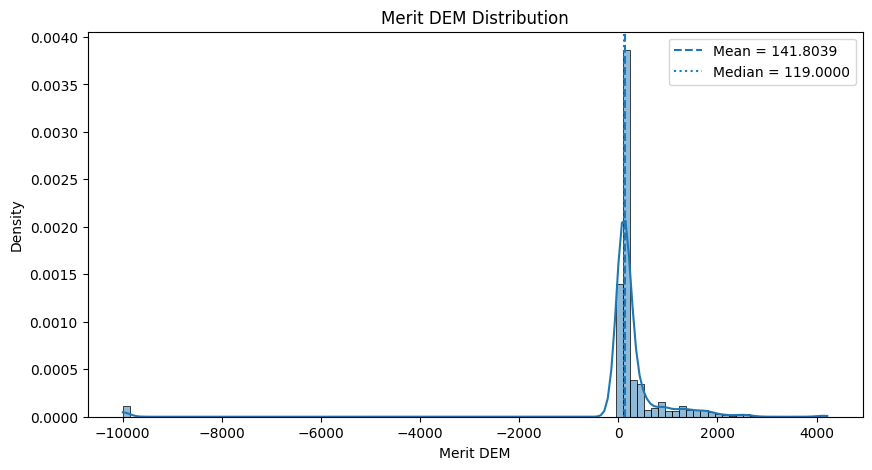

In [69]:
show_distribution("Merit DEM")

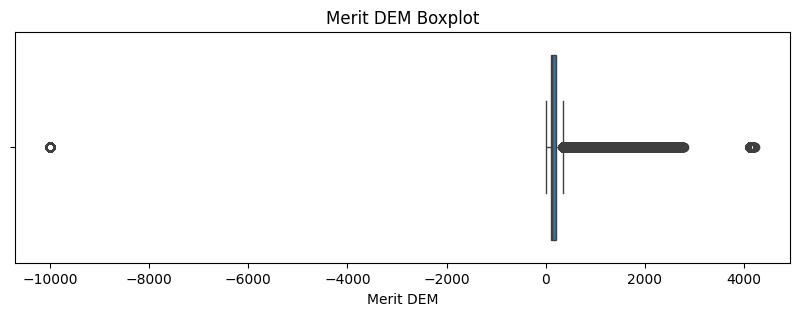

In [70]:
show_boxplot("Merit DEM")

In [71]:
show_quality("Merit DEM")

Channel: Merit DEM
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 77,706 (1.5499%)
Zero values: 975 (0.0194%)
Values beyond ±3 STD: 77,716 (1.5501%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 10. Copernicus DEM

Copernicus DEM provides elevation information.

It is a continuous numerical feature.

Elevation can contribute useful spatial/topographic information for flood and water segmentation because terrain characteristics can influence where water accumulates.

In [72]:
show_stats("Copernicus DEM")

,Metric,Value
0,Mean,300.741363
1,Median,119.000000
2,Std,496.038807
3,Min,8.000000
4,Max,4287.000000


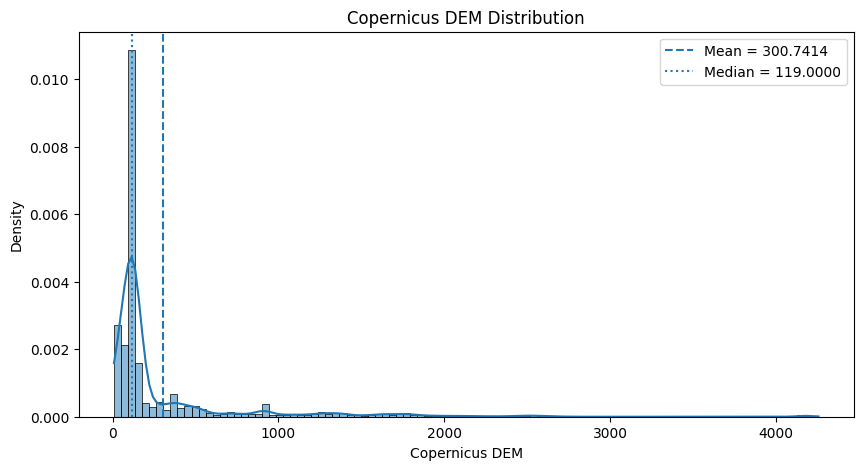

In [73]:
show_distribution("Copernicus DEM")

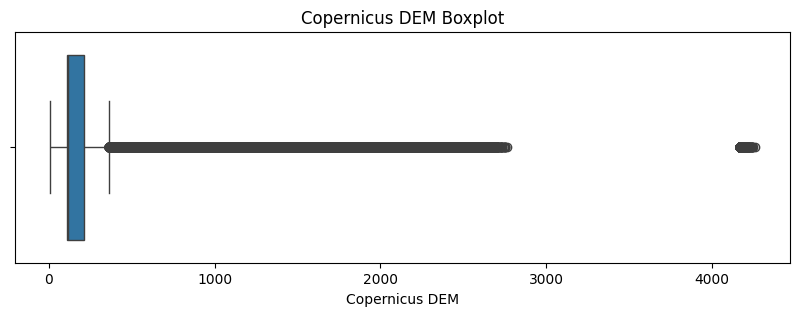

In [74]:
show_boxplot("Copernicus DEM")

In [75]:
show_quality("Copernicus DEM")

Channel: Copernicus DEM
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 0 (0.0000%)
Zero values: 0 (0.0000%)
Values beyond ±3 STD: 125,914 (2.5115%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


## 11. WorldCover

WorldCover represents land-cover information.

Unlike spectral bands, it should generally be treated as a categorical feature because its values represent land-cover classes rather than continuous measurements.

It can provide contextual information that may help distinguish water from other land-cover categories.

In [76]:
show_stats("WorldCover")

,Metric,Value
0,Mean,35.102533
1,Median,40.000000
2,Std,20.184525
3,Min,10.000000
4,Max,100.000000


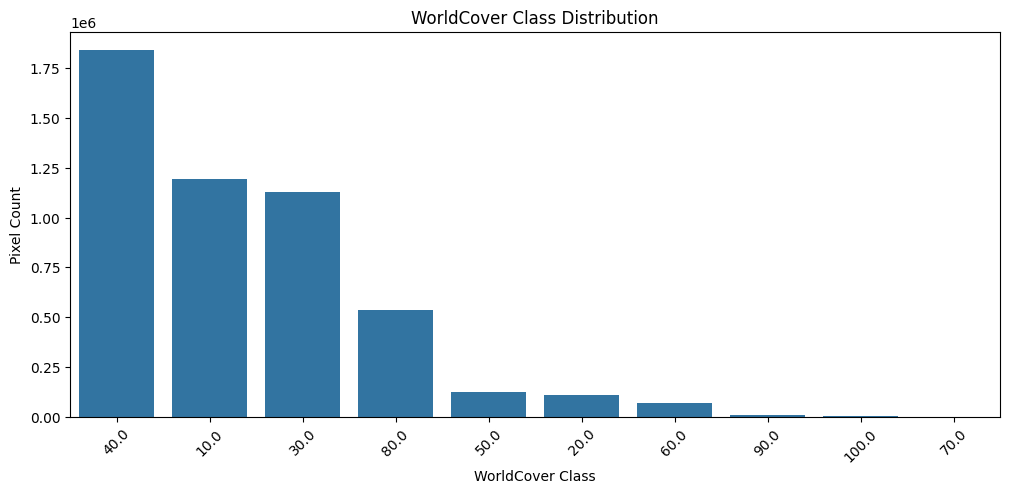

In [79]:
worldcover = pd.to_numeric(
    df_corr["WorldCover"],
    errors="coerce"
).dropna()


plt.figure(figsize=(12, 5))

sns.countplot(
    x=worldcover.astype(str),
    order=worldcover.astype(str).value_counts().index
)

plt.title("WorldCover Class Distribution")
plt.xlabel("WorldCover Class")
plt.ylabel("Pixel Count")
plt.xticks(rotation=45)
plt.show()

In [78]:
worldcover = pd.to_numeric(
    df_corr["WorldCover"],
    errors="coerce"
)

print("Total values:", len(worldcover))

print(
    "Missing values:",
    worldcover.isna().sum(),
    f"({worldcover.isna().mean()*100:.4f}%)"
)

print("\nClass frequencies:")
display(
    worldcover
    .value_counts(dropna=False)
    .sort_index()
)

Total values: 5013504
Missing values: 0 (0.0000%)

Class frequencies:


,count
WorldCover,
10.0,1191684
20.0,112322
30.0,1128291
40.0,1839547
50.0,123071
60.0,70381
70.0,27
80.0,535069
90.0,10222


## 12. Water Occurrence

Water Occurrence represents information about the frequency/probability of water occurrence.

It is treated as a continuous numerical feature in this analysis.

This feature can be directly relevant to water segmentation because it provides prior information about how frequently water has historically occurred in a location.

In [81]:
show_stats("Water Occurrence")

,Metric,Value
0,Mean,9.753326
1,Median,0.000000
2,Std,27.758307
3,Min,0.000000
4,Max,111.000000


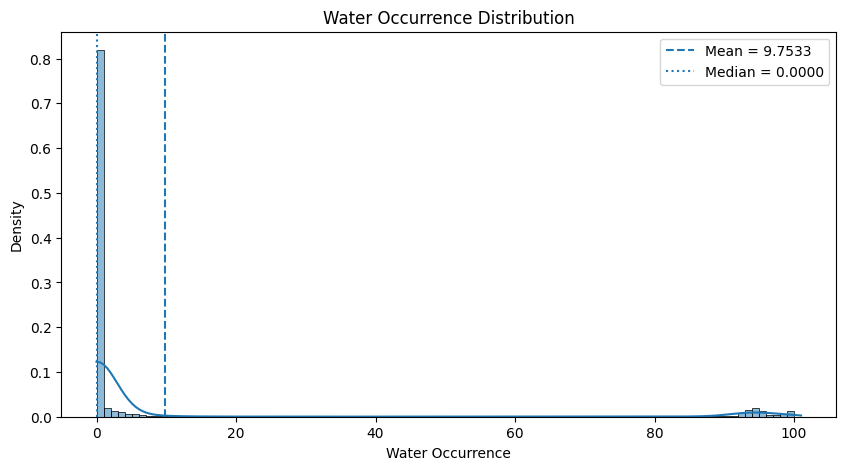

In [82]:
show_distribution("Water Occurrence")

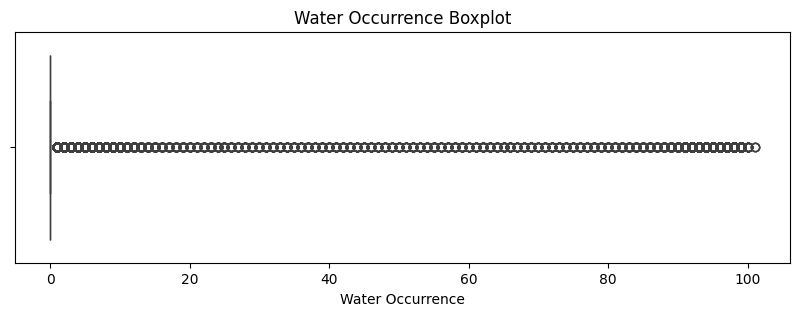

In [83]:
show_boxplot("Water Occurrence")

In [84]:
show_quality("Water Occurrence")

Channel: Water Occurrence
Total values: 5,013,504
Non-finite values (NaN/Inf): 0 (0.0000%)
Negative values: 0 (0.0000%)
Zero values: 3,985,303 (79.4914%)
Values beyond ±3 STD: 302,610 (6.0359%)

Note: Values beyond ±3 STD are flagged for inspection only; they are NOT automatically considered invalid or removed.


In [85]:
summary = []

for channel in channel_names:

    s, values = get_values(channel)

    mean = np.mean(values)
    median = np.median(values)
    std = np.std(values)
    minimum = np.min(values)
    maximum = np.max(values)

    total = len(s)
    arr = s.to_numpy(dtype=float)

    non_finite = np.sum(~np.isfinite(arr))
    negative = np.sum(values < 0)

    if channel in categorical_channels:
        concern = "Categorical / quality feature"
    else:
        extreme = np.sum(
            np.abs(values - mean) > 3 * std
        )

        concerns = []

        if non_finite > 0:
            concerns.append("NaN/Inf")

        if negative > 0:
            concerns.append("Negative values")

        if extreme > 0:
            concerns.append("Extreme values")

        concern = (
            ", ".join(concerns)
            if concerns
            else "No obvious numerical quality issue"
        )

    summary.append({
        "Channel": channel,
        "Type": (
            "Quality/Categorical"
            if channel == "QA Band"
            else "Categorical"
            if channel == "WorldCover"
            else "Continuous"
        ),
        "Mean": mean,
        "Median": median,
        "Std": std,
        "Min": minimum,
        "Max": maximum,
        "Quality Concerns": concern
    })

summary_df = pd.DataFrame(summary)

display(
    summary_df.style.format({
        "Mean": "{:.4f}",
        "Median": "{:.4f}",
        "Std": "{:.4f}",
        "Min": "{:.4f}",
        "Max": "{:.4f}"
    })
)

,Channel,Type,Mean,Median,Std,Min,Max,Quality Concerns
0,Coastal Aerosol,Continuous,396.4677,363.0000,270.0666,-1393.0000,6568.0000,"Negative values, Extreme values"
1,Blue,Continuous,494.6210,458.0000,325.9792,-1169.0000,9659.0000,"Negative values, Extreme values"
2,Green,Continuous,822.3198,775.0000,418.1216,-722.0000,11368.0000,"Negative values, Extreme values"
3,Red,Continuous,973.6750,904.0000,586.7030,-684.0000,12041.0000,"Negative values, Extreme values"
4,NIR,Continuous,2090.1110,2164.0000,1055.9846,-412.0000,15841.0000,"Negative values, Extreme values"
5,SWIR1,Continuous,1964.0506,1987.0000,1191.4223,-335.0000,15252.0000,"Negative values, Extreme values"
6,SWIR2,Continuous,1351.2740,1251.0000,961.7626,-258.0000,14647.0000,"Negative values, Extreme values"
7,QA Band,Quality/Categorical,102.7396,64.0000,48.8040,64.0000,255.0000,Categorical / quality feature
8,Merit DEM,Continuous,141.8039,119.0000,1364.9811,-9999.0000,4245.0000,"Negative values, Extreme values"
9,Copernicus DEM,Continuous,300.7414,119.0000,496.0388,8.0000,4287.0000,Extreme values
